# Sentiment Analysis — TF-IDF Baseline
### Bangla / English / Banglish mixed-language dataset

This notebook builds a **TF-IDF + linear classifier** pipeline for the `content` → `vibe`
sentiment task. It's designed to be the *baseline* every fancier model (embeddings,
fine-tuned transformer) should be compared against.

**Why char n-grams matter here:** the dataset mixes Bangla script, English, and
Banglish (romanized Bangla), plus obfuscated company names (`$parktech`, `S0ftv3nce`).
Word-level TF-IDF alone struggles with this. Character n-grams are robust to spelling
variation, script mixing, and light obfuscation, so they're the backbone of this pipeline.

**Before you run this on your full 2500-row file:** update `DATA_PATH` below. This
notebook was built against a 10-row sample, so cross-validation folds and metrics
will look degenerate until you point it at the real file — that's expected, not a bug.


## 1. Setup

In [1]:

import re
import unicodedata
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## 2. Load data

Point `DATA_PATH` at your full ~2500-row CSV. It must have a `content` column
(the review text) and a `vibe` column (the label).


In [2]:

DATA_PATH = "sentiment_df.csv"  # <-- change to your full dataset path

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(2552, 2)


,content,vibe
0,I've been working at $parktech (under Betopi@ ...,Positive
1,I have seen many negative comments about Betop...,Positive
2,Betopi@ / BdCa11ing / $parktech / S0ftv3nce / ...,Positive
3,Pros\nThis company is good for freshers who ha...,Positive
4,Pros:\nSupportive Management: Encouraging and ...,Positive


In [3]:

# Basic sanity checks
print("Columns:", list(df.columns))
print("\nLabel counts:")
print(df["vibe"].value_counts())
print("\nMissing values:")
print(df.isna().sum())


Columns: ['content', 'vibe']

Label counts:
vibe
Negative    1980
Positive     289
Mixed        283
Name: count, dtype: int64

Missing values:
content    0
vibe       0
dtype: int64


## 3. Quick EDA

Text length and language mix matter a lot for this dataset — some reviews are a
sentence, others are 500+ words. Worth knowing before you pick a truncation strategy
for any downstream transformer model too.


           char_len    word_len     bn_ratio
count   2552.000000  2552.00000  2552.000000
mean    1355.623433   226.53174     0.679797
std     1224.176315   204.47274     0.742164
min       10.000000     2.00000     0.000000
25%      587.250000    99.00000     0.000000
50%     1027.000000   171.00000     0.000000
75%     1762.000000   294.25000     1.523818
max    16819.000000  2728.00000     1.765101


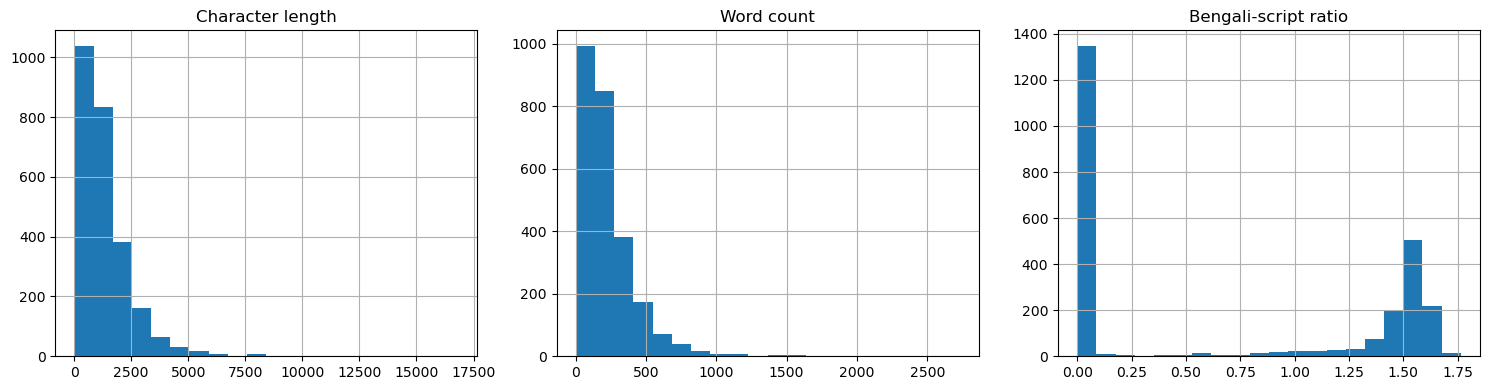

In [4]:

df["char_len"] = df["content"].astype(str).apply(len)
df["word_len"] = df["content"].astype(str).apply(lambda x: len(x.split()))

def bengali_ratio(text):
    text = str(text)
    if len(text) == 0:
        return 0.0
    bengali_chars = sum(1 for ch in text if '\u0980' <= ch <= '\u09FF')
    letters = sum(1 for ch in text if ch.isalpha())
    return bengali_chars / max(letters, 1)

df["bn_ratio"] = df["content"].apply(bengali_ratio)

print(df[["char_len", "word_len", "bn_ratio"]].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
df["char_len"].hist(bins=20, ax=axes[0]); axes[0].set_title("Character length")
df["word_len"].hist(bins=20, ax=axes[1]); axes[1].set_title("Word count")
df["bn_ratio"].hist(bins=20, ax=axes[2]); axes[2].set_title("Bengali-script ratio")
plt.tight_layout()
plt.show()


## 4. Preprocessing

Steps, in order:

1. **Unicode NFC normalize** — collapses Bangla nukta / zero-width-joiner variants
   that otherwise fragment the vocabulary into near-duplicate tokens.
2. **De-obfuscate** leetspeak-style substitutions (`$`→s, `@`→a, `0`→o, `3`→e) so
   `$parktech` and `S0ftv3nce` normalize toward readable forms.
3. **Mask entities** — company names, URLs, emails, phone numbers, money amounts →
   placeholder tokens. This is important: without it, the model can learn
   "this company's name → Negative" instead of learning sentiment, and your score
   will look great but won't generalize past this batch of reviews.
4. **Keep emojis, punctuation, repeated characters** (`!!!`, `😡`) — these carry
   real sentiment signal and TF-IDF with char n-grams picks them up naturally.

Edit `COMPANY_PATTERNS` to match the specific obfuscated names in your full dataset.


In [5]:

# Add any other obfuscated variants you spot in the full 2500 rows here
COMPANY_PATTERNS = [
    r"\$?[Pp]ark\s*[Tt]ech\w*",
    r"[Bb]etop[i1!]a?@?\s*(Group|Limited)?",
    r"[Bb][Dd][Cc]?@?11ing",
    r"[Ss]\$?oftv[e3]nce",
    r"\$?[Mm]\s*[Tt]ech",
    r"[Bb]@?ckventure",
]
COMPANY_RE = re.compile("|".join(COMPANY_PATTERNS))

LEET_MAP = str.maketrans({"$": "s", "@": "a", "0": "o", "3": "e", "1": "i", "!": "i"})

URL_RE = re.compile(r"https?://\S+|www\.\S+")
EMAIL_RE = re.compile(r"\S+@\S+\.\S+")
MONEY_RE = re.compile(r"(৳|\$)\s?\d[\d,]*")
PHONE_RE = re.compile(r"\b0?1[3-9]\d{8}\b")

def preprocess(text):
    text = str(text)
    text = unicodedata.normalize("NFC", text)

    text = COMPANY_RE.sub(" <ORG> ", text)
    text = URL_RE.sub(" <URL> ", text)
    text = EMAIL_RE.sub(" <EMAIL> ", text)
    text = MONEY_RE.sub(" <MONEY> ", text)
    text = PHONE_RE.sub(" <PHONE> ", text)

    # De-obfuscate whatever's left (do this AFTER masking known company names,
    # so we don't accidentally merge de-obfuscated leftovers back into new matches)
    text = text.translate(LEET_MAP)

    # Collapse excessive whitespace/newlines but keep punctuation & emoji
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["content_clean"] = df["content"].apply(preprocess)

# Eyeball a couple of before/after examples
for i in df.index[:2]:
    print("RAW: ", df.loc[i, "content"][:200])
    print("CLEAN:", df.loc[i, "content_clean"][:200])
    print("-" * 80)


RAW:  I've been working at $parktech (under Betopi@ Group) as a developer and team lead for about 14 months now. I know a lot of people have negative opinions about our company, some ex-employees have left 
CLEAN: I've been working at <ORG> (under <ORG> ) as a developer and team lead for about i4 months now. I know a lot of people have negative opinions about our company, some ex-employees have left tough revie
--------------------------------------------------------------------------------
RAW:  I have seen many negative comments about Betopi@ / BDC@lling, so I want to share my personal experience. I worked at SparkTech Agency, which is a part of Betopi@, for almost 1.5 years.
At the beginnin
CLEAN: I have seen many negative comments about <ORG> / BDCalling, so I want to share my personal experience. I worked at S <ORG> Agency, which is a part of <ORG> , for almost i.5 years. At the beginning, th
--------------------------------------------------------------------------------


### 4b. Near-duplicate check

Scraped review data often has near-duplicate posts (same complaint reposted, copy-paste
reviews). If duplicates leak across your train/test split, your test score is inflated.
Run this on the full dataset before splitting.


In [6]:

from difflib import SequenceMatcher

def flag_near_duplicates(texts, threshold=0.92, sample_cap=500):
    """O(n^2) pairwise check — fine up to a few thousand rows.
    For much larger datasets, switch to MinHash (datasketch) instead."""
    n = len(texts)
    dupe_pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            ratio = SequenceMatcher(None, texts[i][:300], texts[j][:300]).ratio()
            if ratio > threshold:
                dupe_pairs.append((i, j, round(ratio, 3)))
    return dupe_pairs

dupes = flag_near_duplicates(df["content_clean"].tolist())
print(f"Found {len(dupes)} near-duplicate pairs")
dupes[:10]


Found 73 near-duplicate pairs


[(14, 104, 1.0),
 (14, 1044, 1.0),
 (14, 1047, 1.0),
 (14, 1049, 1.0),
 (51, 2376, 1.0),
 (104, 1044, 1.0),
 (104, 1047, 1.0),
 (104, 1049, 1.0),
 (181, 195, 1.0),
 (181, 209, 1.0)]

In [7]:

# Drop the second item of each near-duplicate pair (keep the first occurrence)
drop_idx = sorted({j for _, j, _ in dupes})
df = df.drop(index=df.index[drop_idx]).reset_index(drop=True)
print("Shape after dedup:", df.shape)


Shape after dedup: (2518, 6)


## 5. Train / test split

Stratified on the label so class balance is preserved in both splits. With the full
2500-row dataset, an 80/20 split gives a reasonably stable test set; on this 10-row
sample it's mostly illustrative.


In [8]:

X = df["content_clean"]
y = df["vibe"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print(y_train.value_counts())


Train: (2014,) Test: (504,)
vibe
Negative    1560
Positive     230
Mixed        224
Name: count, dtype: int64


## 6. TF-IDF pipeline

Two feature spaces combined:

- **Character n-grams (2–5)** — the main workhorse for code-mixed / misspelled /
  obfuscated text. Robust to script switching mid-sentence.
- **Word n-grams (1–2)** — captures clean multi-word phrases ("work pressure",
  "on time salary") that char n-grams alone can dilute.

`sublinear_tf=True` dampens the effect of very long reviews dominating on raw term
frequency alone.


In [9]:

char_vectorizer = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(2, 5),
    min_df=1,          # raise to 2-3 once you're on the full 2500-row dataset
    sublinear_tf=True,
    max_features=300_000,
)

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=1,           # raise to 2-3 on the full dataset
    sublinear_tf=True,
    token_pattern=r"(?u)\b\w+\b",  # keep single-char tokens (relevant for Bangla)
)

feature_union = FeatureUnion([
    ("char_tfidf", char_vectorizer),
    ("word_tfidf", word_vectorizer),
])


## 7. Model training

Two classifiers, both strong, fast baselines for high-dimensional sparse TF-IDF features:

- **LinearSVC** — usually the best raw accuracy/F1 for TF-IDF text classification.
  Wrapped in `CalibratedClassifierCV` so it can also output probabilities.
- **Logistic Regression** — slightly more interpretable coefficients, good second opinion.

`class_weight="balanced"` matters if your full 2500-row set has label imbalance
(e.g. many more Positive than Negative reviews).


In [10]:

svc_pipeline = Pipeline([
    ("features", feature_union),
    ("clf", CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
        cv=3,
    )),
])

logreg_pipeline = Pipeline([
    ("features", feature_union),
    ("clf", LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE
    )),
])

svc_pipeline.fit(X_train, y_train)
logreg_pipeline.fit(X_train, y_train)
print("Trained both pipelines.")


Trained both pipelines.


## 8. Evaluation on the held-out test set

In [11]:

def evaluate(pipeline, name):
    preds = pipeline.predict(X_test)
    macro_f1 = f1_score(y_test, preds, average="macro")
    acc = accuracy_score(y_test, preds)
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.3f}   Macro-F1: {macro_f1:.3f}")
    print(classification_report(y_test, preds, zero_division=0))
    return preds

svc_preds = evaluate(svc_pipeline, "LinearSVC")
logreg_preds = evaluate(logreg_pipeline, "Logistic Regression")


=== LinearSVC ===
Accuracy: 0.851   Macro-F1: 0.567
              precision    recall  f1-score   support

       Mixed       0.60      0.05      0.10        56
    Negative       0.88      0.99      0.93       391
    Positive       0.68      0.67      0.67        57

    accuracy                           0.85       504
   macro avg       0.72      0.57      0.57       504
weighted avg       0.82      0.85      0.81       504

=== Logistic Regression ===
Accuracy: 0.843   Macro-F1: 0.575
              precision    recall  f1-score   support

       Mixed       0.44      0.12      0.19        56
    Negative       0.88      0.99      0.93       391
    Positive       0.64      0.56      0.60        57

    accuracy                           0.84       504
   macro avg       0.65      0.56      0.57       504
weighted avg       0.80      0.84      0.81       504



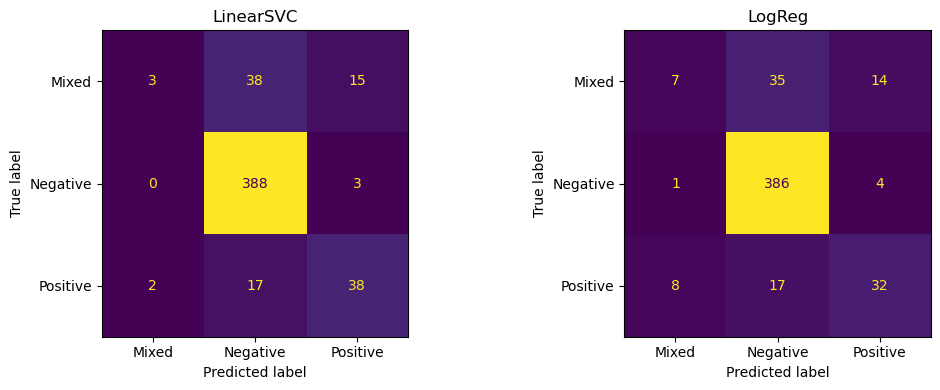

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, preds, name in zip(axes, [svc_preds, logreg_preds], ["LinearSVC", "LogReg"]):
    cm = confusion_matrix(y_test, preds, labels=sorted(y.unique()))
    ConfusionMatrixDisplay(cm, display_labels=sorted(y.unique())).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


## 9. Cross-validation (more reliable than a single split)

With only ~2500 rows, one train/test split has real variance — macro-F1 can swing
a few points just from which rows landed in the test set. 5-fold stratified CV on the
whole dataset gives a steadier estimate. **This needs the full dataset to be meaningful
— skip / expect noisy numbers on the 10-row sample.**


In [13]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_pipeline = Pipeline([
    ("features", feature_union),
    ("clf", LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)),
])

cv_scores = cross_val_score(cv_pipeline, X, y, cv=cv, scoring="f1_macro")
print("Per-fold macro-F1:", np.round(cv_scores, 3))
print(f"Mean: {cv_scores.mean():.3f}  Std: {cv_scores.std():.3f}")


Per-fold macro-F1: [0.561 0.553 0.548 0.554 0.557]
Mean: 0.554  Std: 0.004


## 10. Error analysis

Look at what the model got wrong. On mixed-language data, errors often cluster by
language (pure Bangla vs pure English vs code-mixed) — worth checking explicitly, since
an aggregate score can hide a model that's basically failing on one language entirely.


In [14]:

error_df = pd.DataFrame({
    "text": X_test.values,
    "true": y_test.values,
    "pred": svc_preds,
})
error_df["bn_ratio"] = error_df["text"].apply(bengali_ratio)
errors = error_df[error_df["true"] != error_df["pred"]]

print(f"{len(errors)} / {len(error_df)} test examples misclassified")
pd.set_option("display.max_colwidth", 150)
errors[["text", "true", "pred", "bn_ratio"]].head(20)


75 / 504 test examples misclassified


,text,true,pred,bn_ratio
0,I have been with this company for over 5 years. Pros: Flexible working hours Hybrid/WFH option (varies from team to team) Cons: Job pressure depen...,Mixed,Positive,0.000000
12,"Cefaio isn’t perfect—no company is—but overall, it’s a solid place to work. The company genuinely cares for its employees in many ways, and I’d sa...",Mixed,Positive,0.000000
14,জীবনের প্রতিটি যাত্রার পেছনে থাকে গল্প। আমার নিজের গল্পটাও শুরু হয়েছিল এক সাধারণ পদ থেকে— ঘরের বাজারের কল সেন্টারে একজন এক্সিকিউটিভ হিসেবে। তখন ব...,Positive,Negative,1.571596
20,"I had the opportunity to work at Technonext Ltd. for almost two years. Like any organization, it has its strengths and areas for improvement, but ...",Mixed,Positive,0.000000
30,"Pros Unlimited caffeine and food. Sports room and a Play room with a PS5, perfect for decompressing after a hard day of eating, shitting, and edit...",Positive,Negative,0.000000
40,"i. Hires based on skill, gives opportunity to freshers. 2. Let us work on real world project from the start. So great opportunity build up profile...",Mixed,Positive,0.000000
41,"The desks are arranged in such a way that the management can look into the monitor of most employees. Like man, you need to trust me and assign me...",Mixed,Negative,0.000000
63,"Here's some honest rant, I mean this company has offices in e-4 countries, but the main manpower (like 7o%) is from bangladesh (hello cheap labor ...",Mixed,Negative,0.000000
64,I appeared for an interview and was offered a good package. I also got the vibe that the resources are valued as human beings here. Though it was ...,Positive,Negative,0.000000
68,Foodpanda আমার দেখা বাংলাদেশের সবচেয়ে ট্যালেন্টেড রিসোর্স ওয়ালা একটা কোম্পানিi তাদের ওইখানে এইচ আর এঁর হেড হান্ট করার দক্ষতা মারাত্মকi দেশের আর ...,Mixed,Negative,1.488603


In [15]:

# Macro-F1 broken down by rough language bucket
def lang_bucket(r):
    if r > 0.6:
        return "bangla_dominant"
    elif r < 0.1:
        return "english_dominant"
    return "mixed"

error_df["lang_bucket"] = error_df["bn_ratio"].apply(lang_bucket)

for bucket, group in error_df.groupby("lang_bucket"):
    if len(group) == 0:
        continue
    f1 = f1_score(group["true"], group["pred"], average="macro", zero_division=0)
    print(f"{bucket:18s}  n={len(group):3d}  macro-F1={f1:.3f}")


bangla_dominant     n=232  macro-F1=0.521
english_dominant    n=259  macro-F1=0.580
mixed               n= 13  macro-F1=1.000


## 11. Most predictive features (sanity check, not just performance)

Worth inspecting the top TF-IDF weighted terms per class. If the top features are
mostly the `<ORG>` placeholder or a company-specific proper noun that slipped past
masking, that's a signal of leakage worth fixing before trusting the score.


In [16]:

logreg_only = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
X_train_feats = feature_union.fit_transform(X_train)
logreg_only.fit(X_train_feats, y_train)

feature_names = feature_union.get_feature_names_out()
classes = logreg_only.classes_

if len(classes) == 2:
    coefs = logreg_only.coef_[0]
    top_pos = np.argsort(coefs)[-15:][::-1]
    top_neg = np.argsort(coefs)[:15]
    print(f"Top features → {classes[1]}:")
    print([feature_names[i] for i in top_pos])
    print(f"\nTop features → {classes[0]}:")
    print([feature_names[i] for i in top_neg])
else:
    for ci, cls in enumerate(classes):
        top = np.argsort(logreg_only.coef_[ci])[-15:][::-1]
        print(f"Top features → {cls}:")
        print([feature_names[i] for i in top])
        print()


Top features → Mixed:
['word_tfidf__iii', 'word_tfidf__ভ ল', 'word_tfidf__internal', 'word_tfidf__ল ন', 'word_tfidf__ল ক', 'word_tfidf__খ ব', 'word_tfidf__bad', 'word_tfidf__দ ক', 'word_tfidf__sales', 'word_tfidf__pros', 'word_tfidf__benefits', 'word_tfidf__ব ব', 'word_tfidf__মন স', 'word_tfidf__not', 'word_tfidf__food']

Top features → Negative:
['word_tfidf__no', 'word_tfidf__he', 'word_tfidf__কর', 'word_tfidf__any', 'word_tfidf__their', 'word_tfidf__পর', 'word_tfidf__employees', 'word_tfidf__then', 'word_tfidf__they', 'word_tfidf__his', 'word_tfidf__ট ক', 'word_tfidf__দ ধ', 'word_tfidf__চ কর', 'char_tfidf__ “', 'word_tfidf__ন ই']

Top features → Positive:
['word_tfidf__great', 'word_tfidf__friendly', 'word_tfidf__আম', 'word_tfidf__working', 'word_tfidf__আম র', 'word_tfidf__overall good', 'word_tfidf__good', 'word_tfidf__we', 'char_tfidf__great', 'char_tfidf__grea', 'char_tfidf__ grea', 'char_tfidf__ frie', 'char_tfidf__frie', 'word_tfidf__a great', 'char_tfidf__ fri']



## 12. Save the pipeline

Persist the fitted TF-IDF + classifier pipeline for reuse or as a baseline reference
when you compare against embedding-based and transformer models.


In [17]:

import joblib

joblib.dump(svc_pipeline, "tfidf_sentiment_pipeline.joblib")
print("Saved to tfidf_sentiment_pipeline.joblib")


Saved to tfidf_sentiment_pipeline.joblib


## Next steps

- Re-run this notebook against the full ~2500-row CSV (just change `DATA_PATH`) — the
  10-row sample is too small for the CV and error-analysis sections to mean anything.
- Tune `min_df` / `max_features` / `ngram_range` on the full dataset via `GridSearchCV`.
- Treat this pipeline's macro-F1 as the **floor**: any embedding-based or fine-tuned
  transformer approach should be judged against whether it clears this baseline by
  a meaningful margin, not just whether its number looks high in isolation.
